In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import astropy.units as u
import astropy.constants as const
import pandas as pd
import pickle as pkl
import seaborn as sns
import matplotlib as mpl
from lmfit import Model
from cycler import cycler

# Convenience Functions

In [2]:
def mask_contamination(labline, mask_dict):
    mask_idx = mask_dict[labline]
    if isinstance(mask_idx, list):
        mask=np.ones(300, dtype=bool)
        mask[mask_idx[0]:mask_idx[1]] = False
        return mask
    else:
        mask=np.zeros(300, dtype=bool)
        mask[mask_idx:] = True
        return mask
    
# labline: mask array
line_mask_dict = {
    1453.1:200,
    1555.89:[75,175],
    1463.83:200,
    1613.72:[75,200],
    1415.33:180,
    1407.29:200,
    1468.39:[75,299], #mask out MgII transition at 1466.55
    1407.29: [75,250],
    1435.05: [80,299], #High velocity component
    1636.34: [75,190]
}

In [3]:
def radial_velocity(wavelengths, labline):
    velocity = (wavelengths - labline*u.AA)/(labline*u.AA) * const.c.to(u.km/u.s)
    return velocity

def radial_velocity_error(errors, labline):
    vel_error = np.abs((const.c.to(u.km/u.s))/(labline*u.AA))*errors
    return vel_error

def gaussian(x, amp, sig, cen, bgl):
    x = np.array(x)
    y = amp * np.exp(-((x - cen)**2.0)/(2.0 * (sig**2.0))) + bgl
    return y

In [4]:
def make_gauss_from_params(x, params):
    if len(params) == 4:
        return gaussian(x, params['amp'][0], params['sig'][0], params['cen'][0], params['bgl'][0])
    if len(params) == 7:
        return [gaussian(x, params['amp1'][0], params['sig1'][0], params['cen1'][0], params['bgl'][0]), gaussian(x, params['amp2'][0], params['sig2'][0], params['cen2'][0], params['bgl'][0])]

In [5]:
def calculate_chi2(df):
    chi2_single = []
    chi2_double = []
    red_chi2_single = []
    red_chi2_double = []

    for _, row in df.iterrows():
        f_obs = np.array(row['flux'], dtype=float)
        f_err = np.array(row['fluxerr'], dtype=float)
        f_model_single = np.array(row['gauss_flux'], dtype=float)
        f_model_double = np.array(row['double_gauss_flux'], dtype=float)

        # apply mask if labline has one
        if row['labline'] in line_mask_dict.keys():
            mask = mask_contamination(row['labline'], line_mask_dict)
            f_obs = f_obs[~mask]
            f_err = f_err[~mask]

        chi2_1 = np.sum(((f_obs - f_model_single) / f_err) ** 2)
        chi2_2 = np.sum(((f_obs - f_model_double) / f_err) ** 2)
        chi2_single.append(chi2_1)
        chi2_double.append(chi2_2)

        #calculate reeduced chi2
        red_chi2_1 = chi2_1/(len(f_obs) - len(row['params1']))
        red_chi2_2 = chi2_2/(len(f_obs) - len(row['params2']))
        red_chi2_single.append(red_chi2_1)
        red_chi2_double.append(red_chi2_2)

    return red_chi2_single, red_chi2_double

In [44]:
def plot_fits(df, transition, plot_vel=False):
    subset = df[df['transition']==transition].reset_index(drop=True)
    #chi2 values to add to residuals plot
    chi2_1, chi2_2 = calculate_chi2(subset)
    for i, row in subset.iterrows():
        flux = row['flux'].value
        fluxerr = row['fluxerr'].value
        wave = row['wavelength']#.value
        vel_data = radial_velocity(wave, row['labline']).value
        
        ygauss = row['gauss_flux'].value
        ygausserr = row['gauss_fluxerr'].value

        y2gauss = row['double_gauss_flux'].value
        y2gausserr = row['double_gauss_fluxerr'].value
        
        waveconv = row['conv_wavelength']#.value
        vel_conv = radial_velocity(waveconv, row['labline']).value

        fig, ax = plt.subplots(2,2, figsize = (9,5), sharex=True, gridspec_kw={'height_ratios':[3,1]}, layout='constrained')
        fig.subplots_adjust(hspace=0, wspace=0)
        if plot_vel:
            #data
            ax[0,0].plot(vel_data, flux, '--', label='emission line')
            ax[0,0].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(vel_data, flux, '--', label='emission line')
            ax[0,1].fill_between(vel_data, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            
            #fits
            ygauss1, ygauss2 = make_gauss_from_params(waveconv, row['params2'])

            ax[0,0].plot(vel_conv, ygauss, label='single conv gauss')
            ax[0,0].fill_between(vel_conv, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(vel_conv, ygauss1, label='1')
            ax[0,1].plot(vel_conv, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(vel_conv, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(vel_conv, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(vel_conv, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,0].legend(loc=1)
            ax[1,1].errorbar(vel_conv, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(vel_conv), max(vel_conv), 'r', '--')
            ax[1,1].legend(loc=1)

            #parameter labels
            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Velocity (km s$^{-1}$)')
        else:
            #data
            ax[0,0].plot(wave.value, flux, '--', label='emission line')
            ax[0,0].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)
            ax[0,1].plot(wave.value, flux, '--', label='emission line')
            ax[0,1].fill_between(wave.value, flux-fluxerr, flux+fluxerr, color='tab:blue', alpha=0.2)

            #fits
            ygauss1, ygauss2 = make_gauss_from_params(wave, row['params2'])

            ax[0,0].plot(waveconv.value, ygauss, label='single conv gauss')
            ax[0,0].fill_between(waveconv.value, ygauss-ygausserr, ygauss+ygausserr, color='red', alpha=0.4,)

            ax[0,1].plot(wave, ygauss1, label='1')
            ax[0,1].plot(wave, ygauss2, label='2')

            ax[0,0].set_title(f"BIC = {row['BIC1']}")
            ax[0,1].set_title(f"BIC = {row['BIC2']}")

            ax[0,1].plot(waveconv.value, y2gauss, label='double conv gauss')
            ax[0,1].fill_between(waveconv.value, y2gauss-y2gausserr, y2gauss+y2gausserr, color='red', alpha=0.4,)

            #residuals
            if row['labline'] in line_mask_dict:
                mask = mask_contamination(row['labline'], line_mask_dict)
                masked_flux = flux[~mask]
                masked_fluxerr = fluxerr[~mask]
            else:
                masked_flux = flux
                masked_fluxerr = fluxerr

            ax[1,0].errorbar(waveconv.value, masked_flux-ygauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_1[i]:0.2f}')
            ax[1,0].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')
            ax[1,1].errorbar(waveconv.value, masked_flux-y2gauss, yerr=masked_fluxerr, ms=5, lw=0, marker='.', elinewidth=0.3, label=rf'$\chi^2_\nu$:{chi2_2[i]:0.2f}')
            ax[1,1].hlines(0, min(waveconv.value), max(waveconv.value), 'r', '--')

            for i, param in enumerate(row['params2']):
                ax[0,1].text(0.05, 0.95-(i*0.05), f"{param} = {row['params2'][param][0]:.2e}",
                                transform=ax[0,1].transAxes, verticalalignment='top')
            
            for i, param in enumerate(row['params1']):
                ax[0,0].text(0.05, 0.95-(i*0.05), f"{param} = {row['params1'][param][0]:.2e}",
                                transform=ax[0,0].transAxes, verticalalignment='top')

            fig.supxlabel(r'Wavelength ($\AA$)')
            
        ax[0,0].legend()
        ax[0,1].legend()
        fig.supylabel(r'Flux ($erg \AA^{-1} s^{-2} cm^{-2}$)')
        fig.suptitle(f"{row['transition']} {row['labline']} {row['obsdate']}")
        ax[1,0].set_ylim(-1e-13,1e-13)
        ax[1,1].set_ylim(-1e-13,1e-13)
        
        ax[0,0].set_ylim(0,1e-12)
        ax[0,1].set_ylim(0,1e-12)
        plt.show()

In [7]:
def vsini(sigma, labline):
    vsini = ((sigma/labline) * const.c.to(u.km/u.s)) #v sini
    return vsini/np.sin(np.radians(16))

def FWHM(sigma):
    return 2*np.sqrt(2*np.log(2))*(sigma)

def vsini_err(sigma_err, labline):
    return ((sigma_err / labline) * const.c.to(u.km/u.s)) / np.sin(np.radians(16))

def FWHM_err(sigma_err):
    return 2 * np.sqrt(2 * np.log(2)) * sigma_err

# Load and Prep data

In [8]:
# line_df = pd.read_pickle(os.path.join('data', 'line_df_local.pkl'))
# blue_df = pd.read_pickle(os.path.join('data', 'blue_df.pkl'))
# red_df = pd.read_pickle(os.path.join('data', 'red_df.pkl'))

line_df = pd.read_pickle(os.path.join('data', 'line_df_coadded_bootstrapped_run2.pkl'))
blue_df = pd.read_pickle(os.path.join('data', 'blue_df_coadded_bootstrapped_run2.pkl'))
red_df = pd.read_pickle(os.path.join('data', 'red_df_coadded_bootstrapped_run2.pkl'))

all_df = pd.concat([blue_df, line_df, red_df])

# prog_df = pd.read_pickle(os.path.join('data', 'line_prog_df_local.pkl'))
# blue_prog_df = pd.read_pickle(os.path.join('data', 'blue_prog_df.pkl'))
# red_prog_df = pd.read_pickle(os.path.join('data', 'red_prog_df.pkl'))

In [9]:
def SNR(signal, noise):
    #normalize the signal
    normsignal = signal/np.max(signal)
    normnoise = noise/np.max(noise)
    return np.mean(normsignal/normnoise)

def snr_mask(df, low, high):
    ratio = df.apply(lambda r: SNR(r['gauss_flux'], r['gauss_fluxerr']) /
                               SNR(r['flux'], r['fluxerr']), axis=1)
    return df[ratio.between(low, high)]

red_df_cut  = snr_mask(red_df,  1.5, 13)
blue_df_cut = snr_mask(blue_df, 1.5, 16)
line_df_cut = snr_mask(line_df, 0.8, 100)
#line_df_coadded_cut = snr_mask(line_df_coadded, 0.8, 100)

def peak_mask(df, thresh):
    ratio = df.apply(lambda r: max(r['gauss_flux'].value)/r['params1']['bgl'][0], axis=1)
    mask = np.array(ratio) > thresh
    return ratio, df[mask].copy()

red_df_ratio, red_df_peak  = peak_mask(red_df_cut,  1.5)
blue_df_ratio, blue_df_peak = peak_mask(blue_df_cut, 1.5)
line_df_ratio, line_df_peak = peak_mask(line_df_cut, 1.5)
#line_df_coadded_ratio, line_df_coadded_peak = peak_mask(line_df_coadded_cut, 1.5)

print(len(red_df), len(red_df_cut), len(red_df_peak))
print(len(line_df), len(line_df_cut), len(line_df_peak))
print(len(blue_df), len(blue_df_cut), len(blue_df_peak))

#print(len(line_df_coadded), len(line_df_coadded_cut), len(line_df_coadded_peak))

12 9 8
43 42 42
7 7 7


In [10]:
all_df_pruned = pd.concat([blue_df_peak, line_df_peak, red_df_peak])

In [14]:
wanted = {'[1,4]', '[0,2]', '[1,7]'}#, '[4,4]'}
BIC_df = line_df_peak[line_df_peak['transition'].astype(str).str.replace(' ', '').isin(wanted)].copy()
#BIC_df = line_df_coadded_peak[line_df_coadded_peak['transition'].astype(str).str.replace(' ', '').isin(wanted)].copy()
print(len(BIC_df))
BIC_percentile = (BIC_df['BIC1'] - BIC_df['BIC2'])/BIC_df['BIC1']
BIC_conf = BIC_df[(BIC_percentile<=0.25) & (BIC_percentile>0)]
print(len(BIC_conf))
BIC_diff = line_df_peak[line_df_peak['BIC2']<line_df_peak['BIC1']]
print(len(BIC_diff))

28
18
24


# Collate narrow and broad components

In [15]:
def sort_BC(df):
    double_gauss_params = df['params2']

    both_BC1 = []
    both_BC2 = []

    for param_dict in double_gauss_params:
        wider = param_dict['sig1'] > param_dict['sig2'] # if gauss1 is broader it will be true
        dimmer = param_dict['amp1'] < param_dict['amp2'] # if gauss1 is dimmer it will be true
        both_BC1.append(wider == True and dimmer == True) # Usually true, frequently not
        both_BC2.append(wider == False and dimmer == False)
        
    both_BC1 = np.array(both_BC1)
    both_BC2 = np.array(both_BC2)

    BC_1_definitely = df[both_BC1]
    BC_2_definitely = df[both_BC2]

    #now only consider unsure lines
    #lines where both is false is unsure
    unsure = df.iloc[np.argwhere((both_BC1 == False) & (both_BC2 == False)).ravel()]
    if len(unsure)>0:
        wider_1 = []
        for param_dict in unsure['params2']:
            wider = param_dict['sig1'] > param_dict['sig2'] # if gauss1 is broader it will be true
            wider_1.append(wider)
        wider_1 = np.array(wider_1)

        BC_1_maybe = unsure[wider_1]
        BC_2_maybe = unsure[~wider_1]
    else:
        BC_1_maybe = None
        BC_2_maybe = None

    return BC_1_definitely, BC_2_definitely, BC_1_maybe, BC_2_maybe

In [16]:
BC_1_conf, BC_2_conf, conf_maybe1, conf_maybe2 = sort_BC(BIC_conf.copy())
BC_1_diff, BC_2_diff, diff_maybe1, diff_maybe2 = sort_BC(BIC_diff.copy())

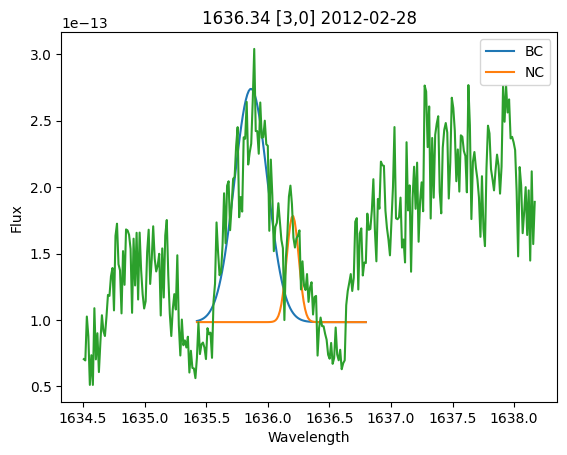

In [17]:
#examine fits that are unsure
for i, row in diff_maybe1.iterrows():
    x = row['conv_wavelength']
    gauss1, gauss2 = make_gauss_from_params(x, row['params2'])
    plt.plot(x, gauss1, label='BC')
    plt.plot(x, gauss2, label='NC')
    plt.plot(row['wavelength'], row['flux'])
    plt.xlabel('Wavelength')
    plt.ylabel('Flux')
    plt.title(str(row['labline']) + ' ' + str(row['transition']) + ' ' + str(row['obsdate']))
    plt.legend()
    plt.show()

In [18]:
#collate all broad component params and NC params separately, do manually for maybes

BC_1_conf['BC_params'] = BC_1_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp1'],
                                                        'sigBC': p['sig1'],
                                                        'cenBC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_1_conf['NC_params'] = BC_1_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp2'],
                                                        'sigNC': p['sig2'],
                                                        'cenNC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )

BC_2_conf['BC_params'] = BC_2_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp2'],
                                                        'sigBC': p['sig2'],
                                                        'cenBC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_2_conf['NC_params'] = BC_2_conf['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp1'],
                                                        'sigNC': p['sig1'],
                                                        'cenNC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_conf = pd.concat([BC_1_conf, BC_2_conf])

In [19]:
BC_1_diff['BC_params'] = BC_1_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp1'],
                                                        'sigBC': p['sig1'],
                                                        'cenBC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_1_diff['NC_params'] = BC_1_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp2'],
                                                        'sigNC': p['sig2'],
                                                        'cenNC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )

BC_2_diff['BC_params'] = BC_2_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampBC': p['amp2'],
                                                        'sigBC': p['sig2'],
                                                        'cenBC': p['cen2'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_2_diff['NC_params'] = BC_2_diff['params2'].apply(
                                                    lambda p: {
                                                        'ampNC': p['amp1'],
                                                        'sigNC': p['sig1'],
                                                        'cenNC': p['cen1'],
                                                        'bgl': p['bgl']
                                                    }
                                                )
BC_diff = pd.concat([BC_1_diff, BC_2_diff])

# NC BC comparison

## Broad Component

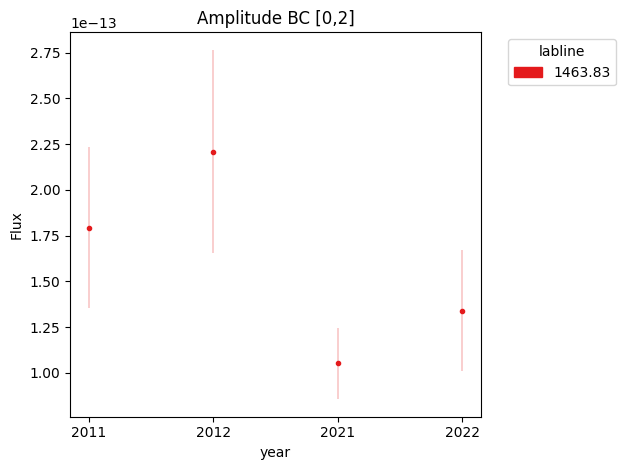

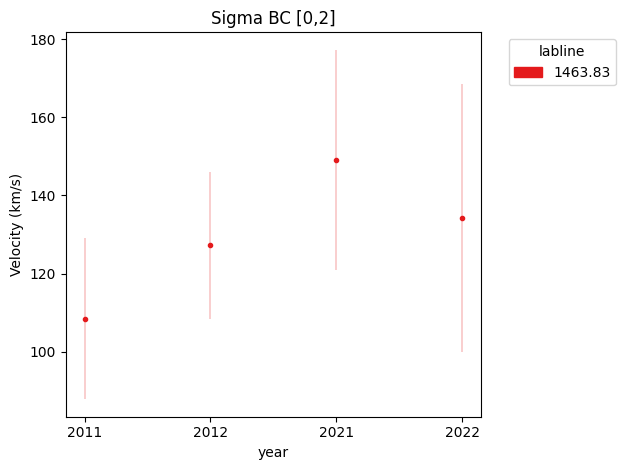

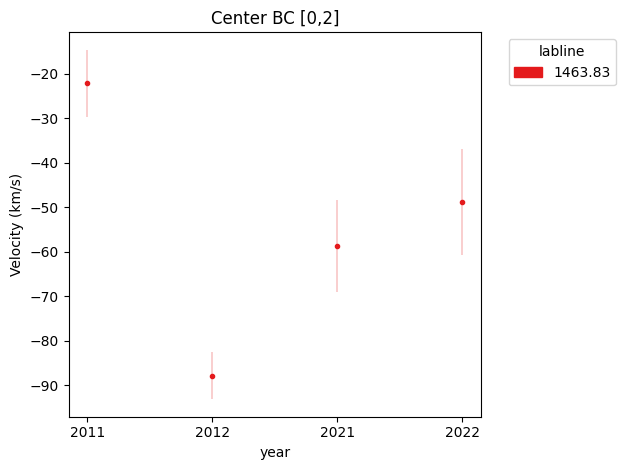

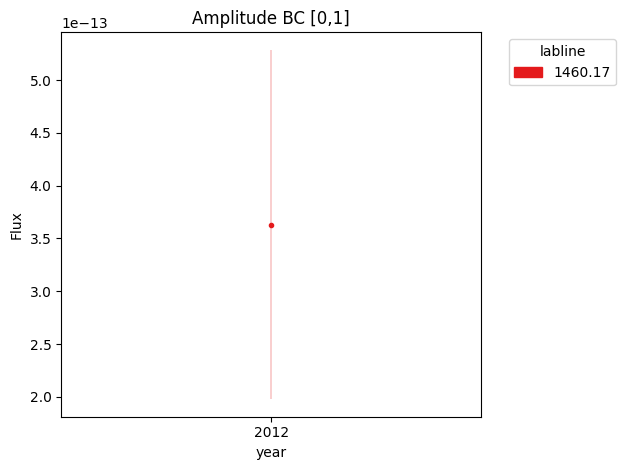

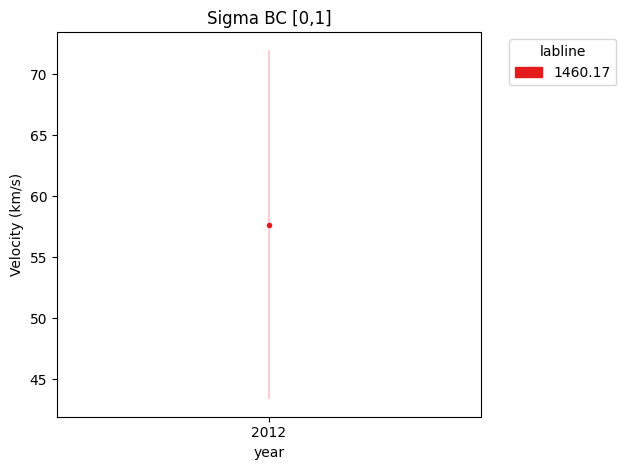

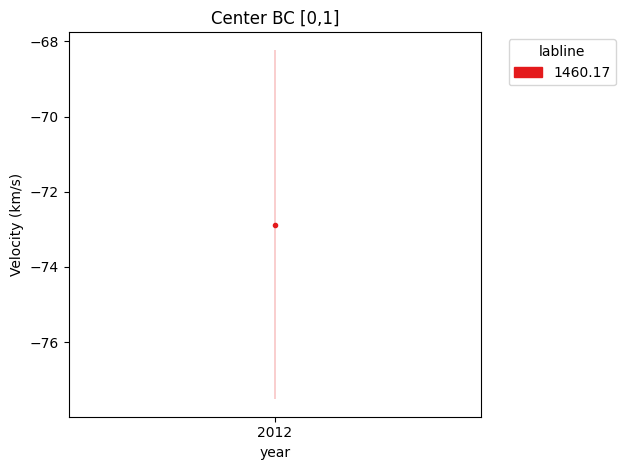

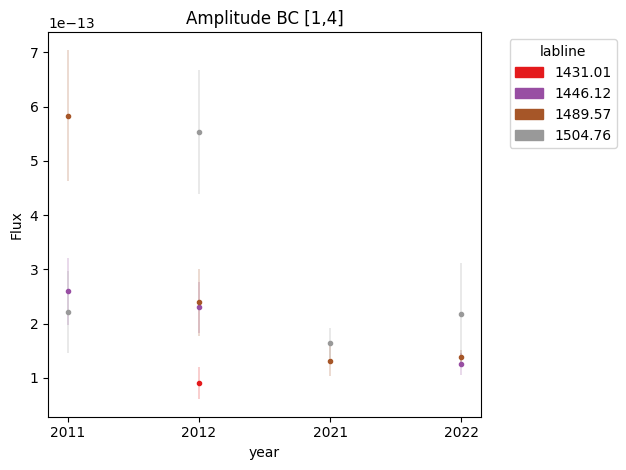

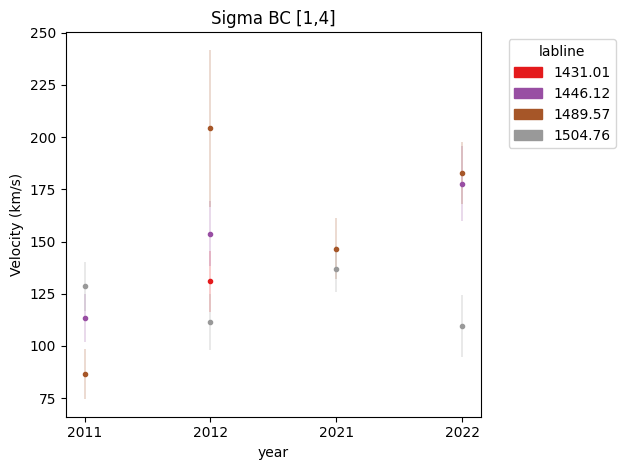

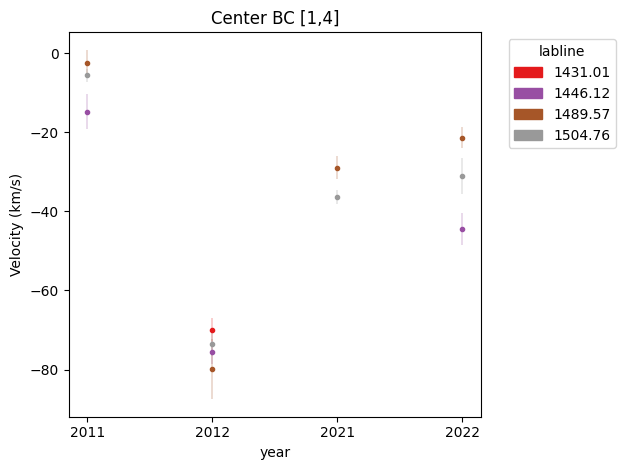

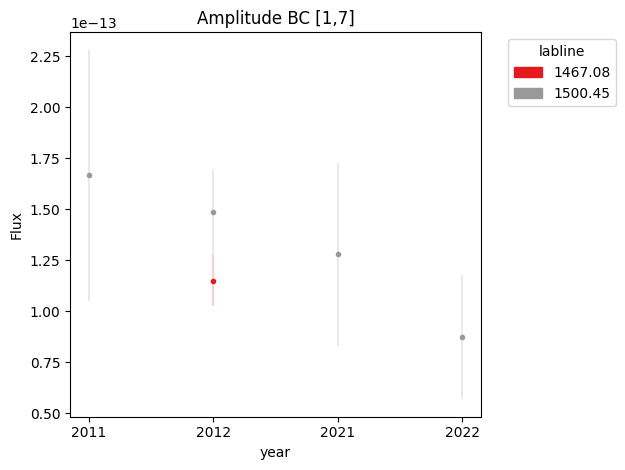

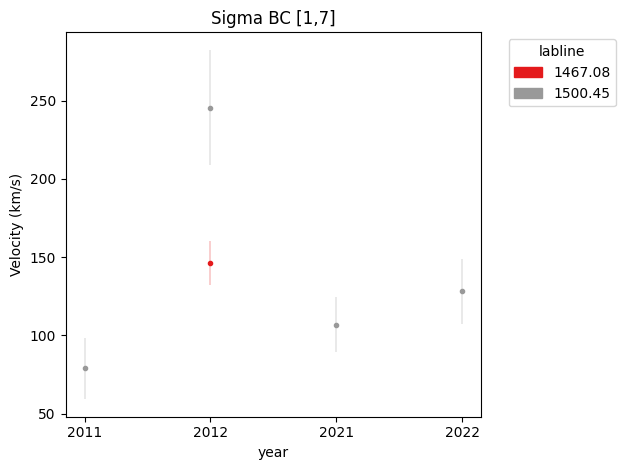

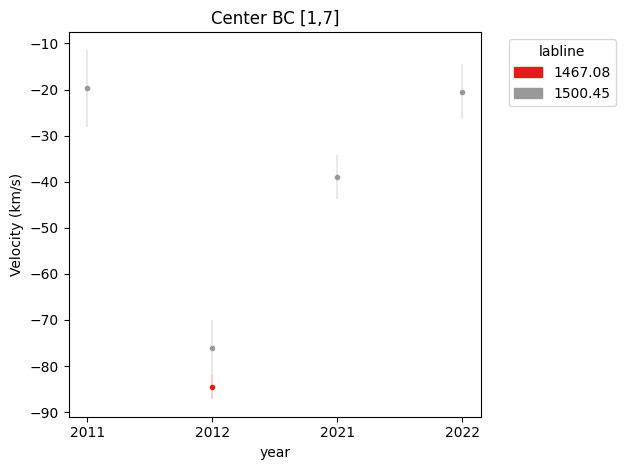

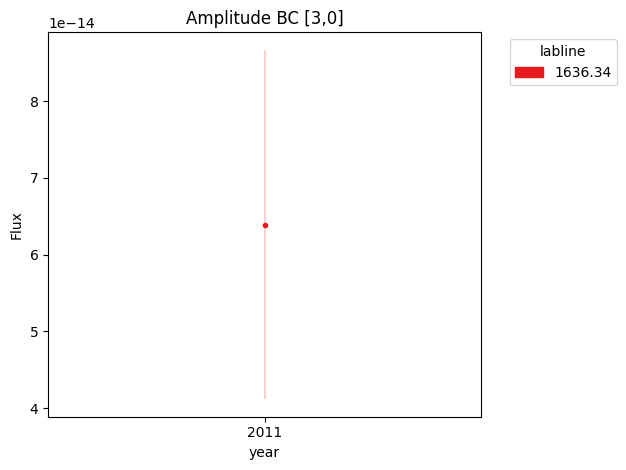

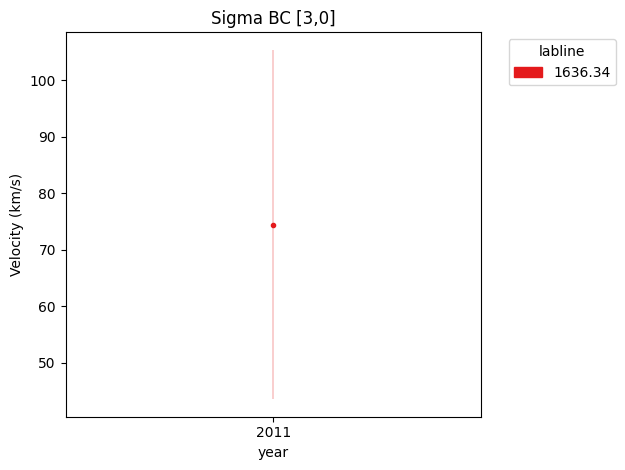

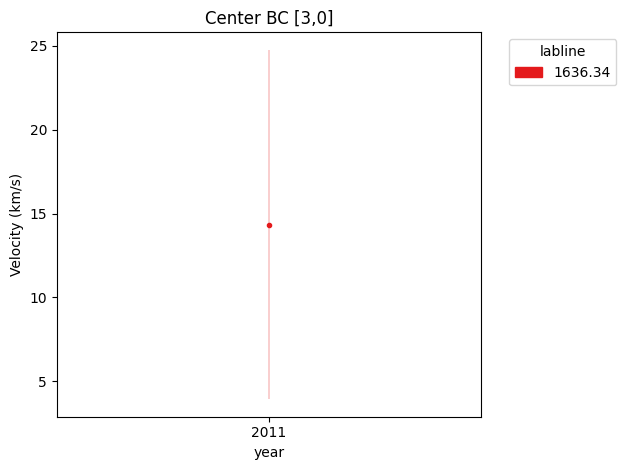

In [31]:
# Compare FWHM, amplitude, and location for component in one progression
df = BC_diff
for transition in df['transition'].unique():
    amps = []
    sigs = []
    cens = []
    cens_vel = []
    amperrs = []
    sigerrs = []
    cenerrs = []
    cenerrs_vel = []

    # Sort by year first to ensure chronological order
    transition_df = df[df['transition'] == transition].sort_values('year')

    # Assign a color to each unique labline
    unique_lablines = sorted(transition_df['labline'].unique())
    cmap = plt.get_cmap('Set1', len(unique_lablines))
    color_map = {lab: cmap(i) for i, lab in enumerate(unique_lablines)}

    for _, row in transition_df.iterrows():
        labline = row['labline']
        item = row['BC_params']
        amps.append(item['ampBC'][0])
        sigs.append(vsini(item['sigBC'][0], labline).value)
        cens.append(item['cenBC'][0])
        amperrs.append(item['ampBC'][1])
        sigerrs.append(vsini_err(item['sigBC'][1], labline).value)
        cenerrs.append(item['cenBC'][1])
        cens_vel.append(radial_velocity(item['cenBC'][0]*u.AA, labline).value)
        cenerrs_vel.append(radial_velocity_error(item['cenBC'][1]*u.AA, labline).value)

    years = transition_df['year'].values
    point_colors = [color_map[lab] for lab in transition_df['labline'].values]
    legend_patches = [mpatches.Patch(color=color_map[lab], label=str(lab)) for lab in unique_lablines]

    for (title, ylabel, ydata, yerrs) in [
        (f'Amplitude BC {transition}', 'Flux',          np.ravel(amps),     amperrs),
        (f'Sigma BC {transition}',     'Velocity (km/s)', np.ravel(sigs),   sigerrs),
        (f'Center BC {transition}',    'Velocity (km/s)', np.ravel(cens_vel), cenerrs_vel),
    ]:
        fig, ax = plt.subplots()
        for i, (x, y, ye, c) in enumerate(zip(years, ydata, yerrs, point_colors)):
            ax.errorbar(x, y, yerr=ye, marker='.', linestyle='', elinewidth=0.3, color=c)
        ax.legend(handles=legend_patches, title='labline', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('year')
        plt.tight_layout()
        plt.show()

In [39]:
print(sorted(set(transitions)))

['[0,1]', '[0,2]', '[1,4]', '[1,7]', '[3,0]']


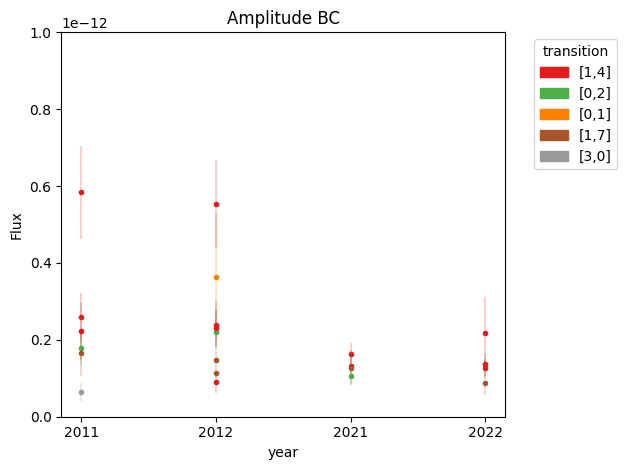

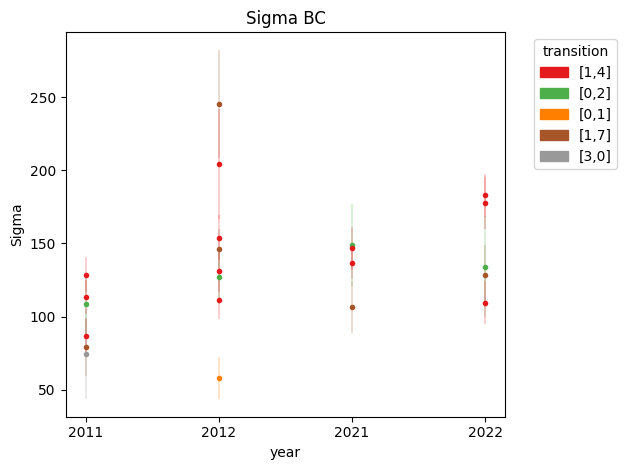

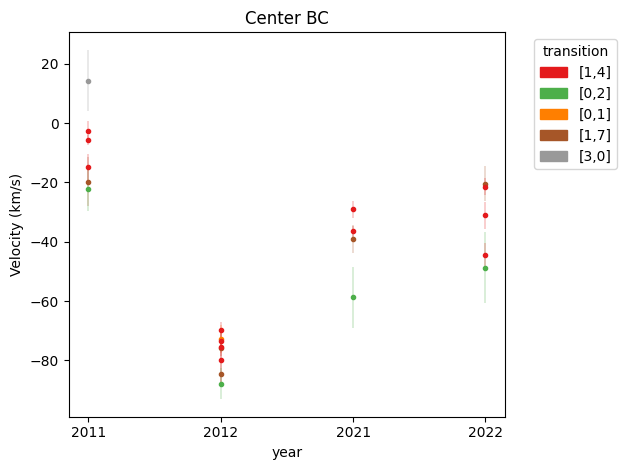

In [ ]:
# Then go across progressions
df = BC_diff.sort_values('year')

amps = []
sigs = []
cens = []
cens_vel = []
amperrs = []
sigerrs = []
cenerrs = []
cenerrs_vel = []
transitions = []

for _, row in df.iterrows():
    labline = row['labline']
    item = row['BC_params']
    amps.append(item['ampBC'][0])
    sigs.append(vsini(item['sigBC'][0], labline).value)
    cens.append(item['cenBC'][0])
    amperrs.append(item['ampBC'][1])
    sigerrs.append(vsini_err(item['sigBC'][1], labline).value)
    cenerrs.append(item['cenBC'][1])
    cens_vel.append(radial_velocity(item['cenBC'][0]*u.AA, labline).value)
    cenerrs_vel.append(radial_velocity_error(item['cenBC'][1]*u.AA, labline).value)
    transitions.append(row['transition'])

# Color by transition
unique_transitions = ['[1,4]', '[0,2]', '[0,1]', '[1,7]', '[3,0]']
cmap = plt.get_cmap('Set1', len(unique_transitions))
color_map = {t: cmap(i) for i, t in enumerate(unique_transitions)}
point_colors = [color_map[t] for t in transitions]
legend_patches = [mpatches.Patch(color=color_map[t], label=str(t)) for t in unique_transitions]

years = df['year'].values

for (title, ylabel, ydata, yerrs, extra_kwargs) in [
    ('Amplitude BC', 'Flux',            np.ravel(amps),      amperrs,     {'ylim': (0, 1e-12)}),
    ('Sigma BC',     'Sigma',           np.ravel(sigs),      sigerrs,     {}),
    ('Center BC',    'Velocity (km/s)', np.ravel(cens_vel),  cenerrs_vel, {}),
]:
    fig, ax = plt.subplots()
    for x, y, ye, c in zip(years, ydata, yerrs, point_colors):
        ax.errorbar(x, y, yerr=ye, marker='.', linestyle='', elinewidth=0.3, color=c)
    if 'ylim' in extra_kwargs:
        ax.set_ylim(extra_kwargs['ylim'])
    ax.legend(handles=legend_patches, title='transition', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('year')
    plt.tight_layout()
    plt.show()

## Narrow Component

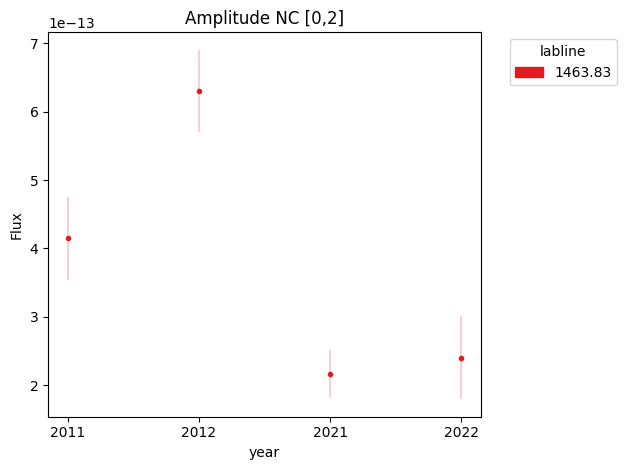

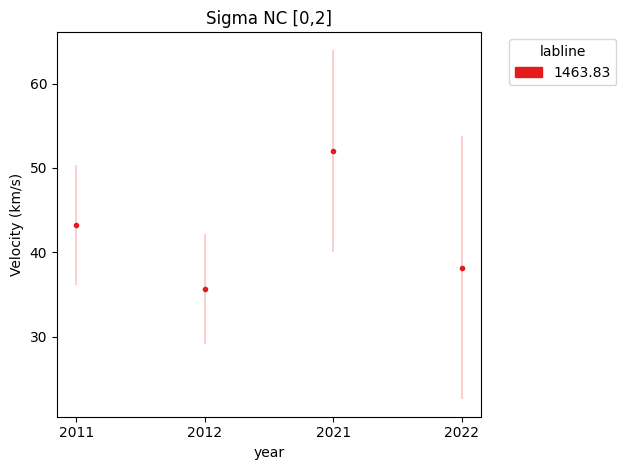

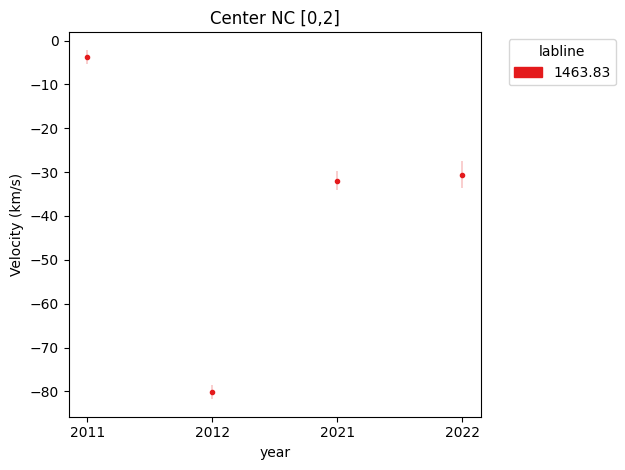

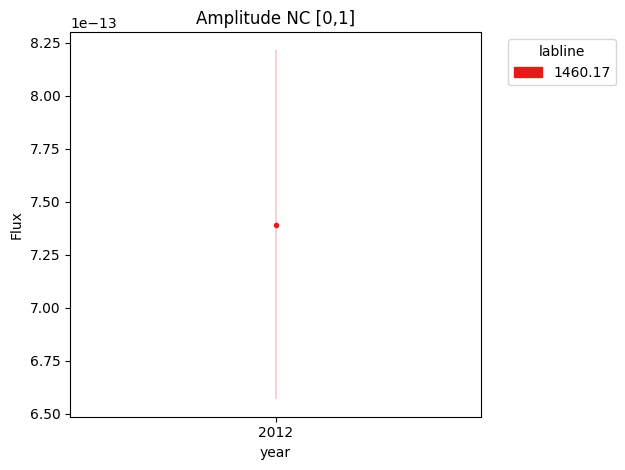

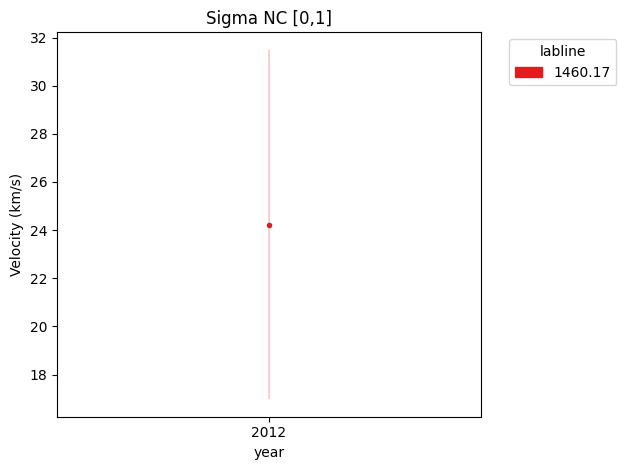

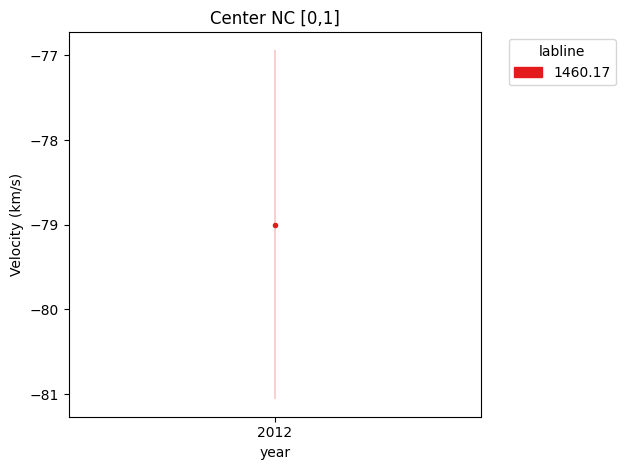

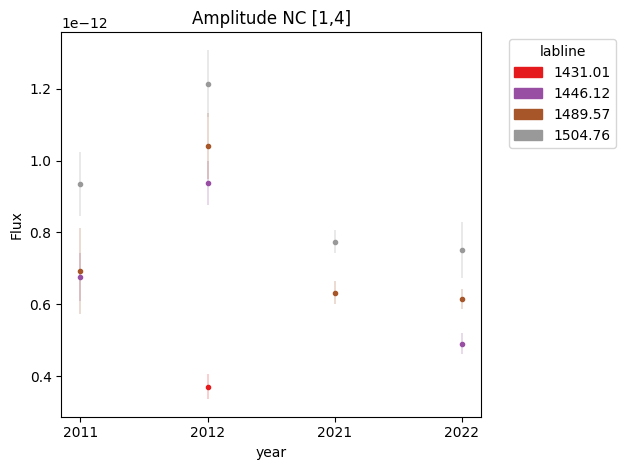

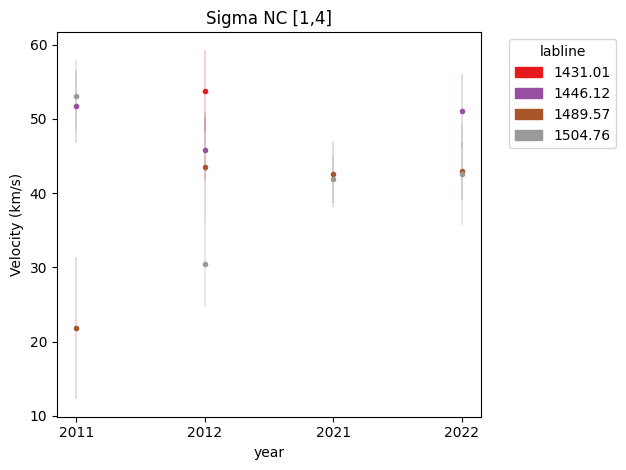

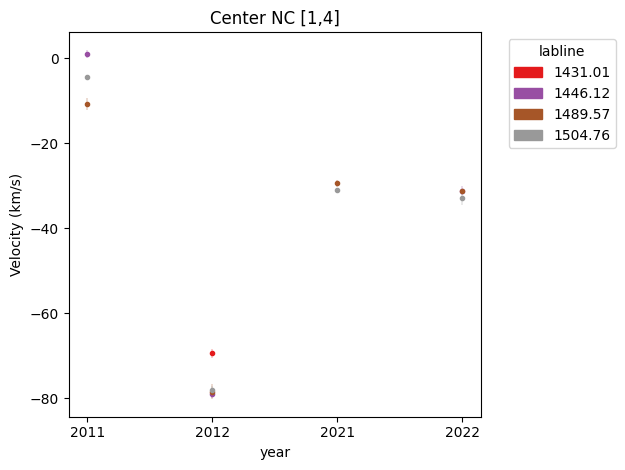

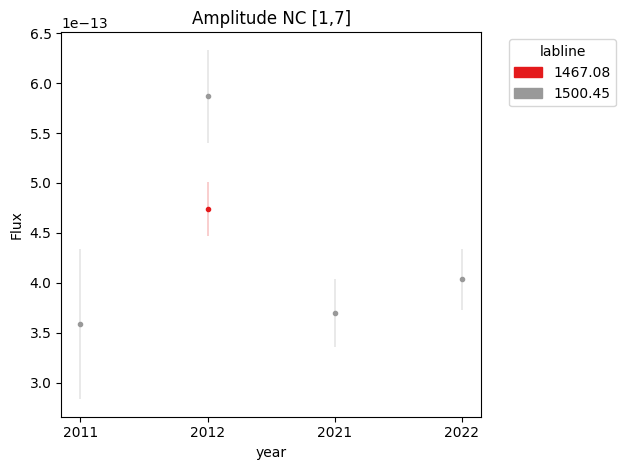

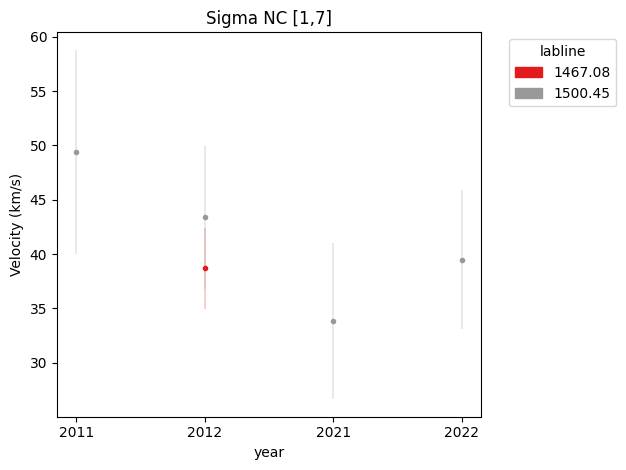

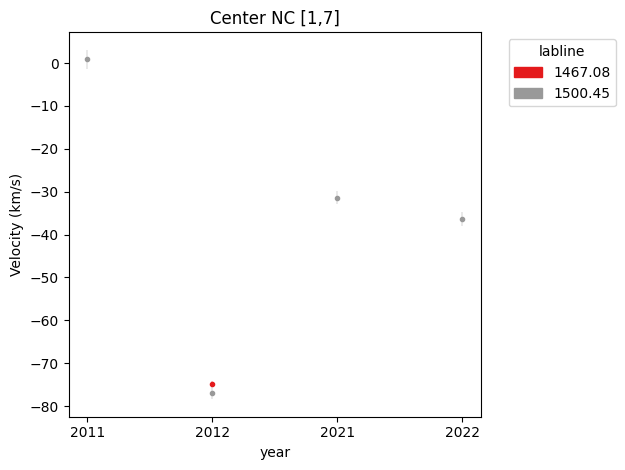

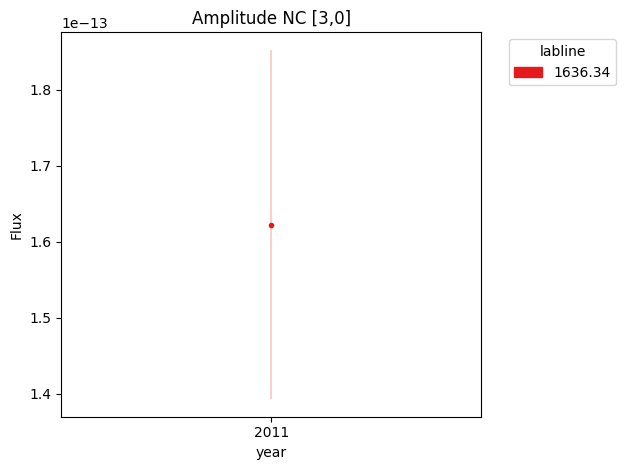

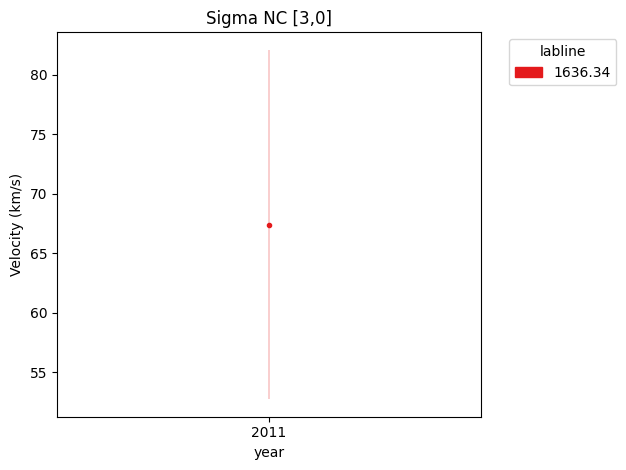

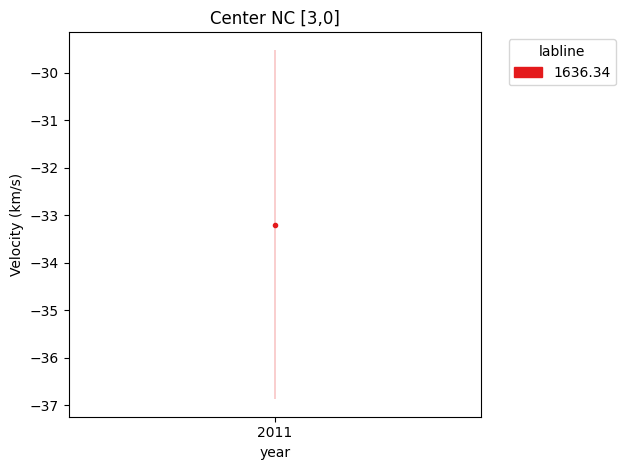

In [47]:
# Compare FWHM, amplitude, and location for component in one progression
df = BC_diff
for transition in df['transition'].unique():
    amps = []
    sigs = []
    cens = []
    cens_vel = []
    amperrs = []
    sigerrs = []
    cenerrs = []
    cenerrs_vel = []

    # Sort by year first to ensure chronological order
    transition_df = df[df['transition'] == transition].sort_values('year')

    # Assign a color to each unique labline
    unique_lablines = sorted(transition_df['labline'].unique())
    cmap = plt.get_cmap('Set1', len(unique_lablines))
    color_map = {lab: cmap(i) for i, lab in enumerate(unique_lablines)}

    for _, row in transition_df.iterrows():
        labline = row['labline']
        item = row['NC_params']
        amps.append(item['ampNC'][0])
        sigs.append(vsini(item['sigNC'][0], labline).value)
        cens.append(item['cenNC'][0])
        amperrs.append(item['ampNC'][1])
        sigerrs.append(vsini_err(item['sigNC'][1], labline).value)
        cenerrs.append(item['cenNC'][1])
        cens_vel.append(radial_velocity(item['cenNC'][0]*u.AA, labline).value)
        cenerrs_vel.append(radial_velocity_error(item['cenNC'][1]*u.AA, labline).value)

    years = transition_df['year'].values
    point_colors = [color_map[lab] for lab in transition_df['labline'].values]
    legend_patches = [mpatches.Patch(color=color_map[lab], label=str(lab)) for lab in unique_lablines]

    for (title, ylabel, ydata, yerrs) in [
        (f'Amplitude NC {transition}', 'Flux',          np.ravel(amps),     amperrs),
        (f'Sigma NC {transition}',     'Velocity (km/s)', np.ravel(sigs),   sigerrs),
        (f'Center NC {transition}',    'Velocity (km/s)', np.ravel(cens_vel), cenerrs_vel),
    ]:
        fig, ax = plt.subplots()
        for i, (x, y, ye, c) in enumerate(zip(years, ydata, yerrs, point_colors)):
            ax.errorbar(x, y, yerr=ye, marker='.', linestyle='', elinewidth=0.3, color=c)
        ax.legend(handles=legend_patches, title='labline', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('year')
        plt.tight_layout()
        plt.show()

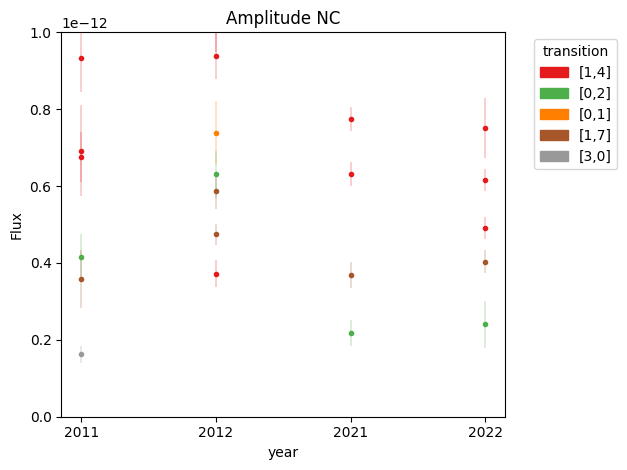

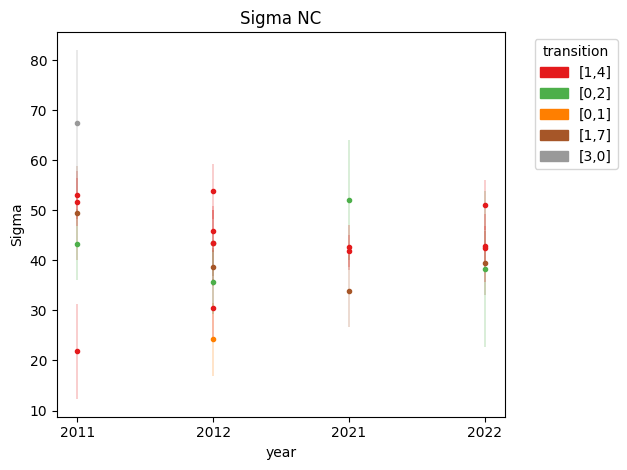

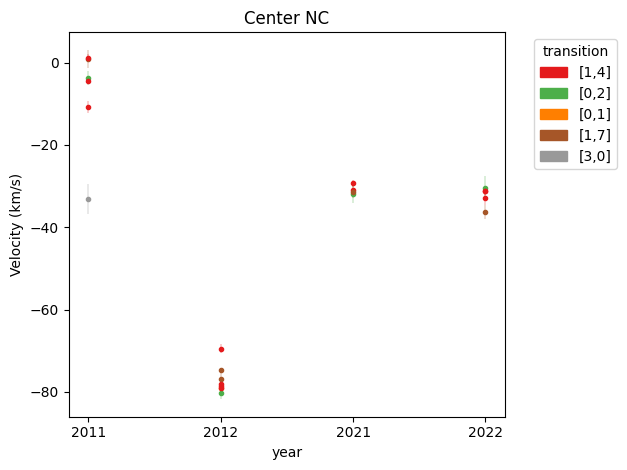

In [46]:
# Then go across progressions
df = BC_diff.sort_values('year')

amps = []
sigs = []
cens = []
cens_vel = []
amperrs = []
sigerrs = []
cenerrs = []
cenerrs_vel = []
transitions = []

for _, row in df.iterrows():
    labline = row['labline']
    item = row['NC_params']
    amps.append(item['ampNC'][0])
    sigs.append(vsini(item['sigNC'][0], labline).value)
    cens.append(item['cenNC'][0])
    amperrs.append(item['ampNC'][1])
    sigerrs.append(vsini_err(item['sigNC'][1], labline).value)
    cenerrs.append(item['cenNC'][1])
    cens_vel.append(radial_velocity(item['cenNC'][0]*u.AA, labline).value)
    cenerrs_vel.append(radial_velocity_error(item['cenNC'][1]*u.AA, labline).value)
    transitions.append(row['transition'])

# Color by transition
unique_transitions = ['[1,4]', '[0,2]', '[0,1]', '[1,7]', '[3,0]']
cmap = plt.get_cmap('Set1', len(unique_transitions))
color_map = {t: cmap(i) for i, t in enumerate(unique_transitions)}
point_colors = [color_map[t] for t in transitions]
legend_patches = [mpatches.Patch(color=color_map[t], label=str(t)) for t in unique_transitions]

years = df['year'].values

for (title, ylabel, ydata, yerrs, extra_kwargs) in [
    ('Amplitude NC', 'Flux',            np.ravel(amps),      amperrs,     {'ylim': (0, 1e-12)}),
    ('Sigma NC',     'Sigma',           np.ravel(sigs),      sigerrs,     {}),
    ('Center NC',    'Velocity (km/s)', np.ravel(cens_vel),  cenerrs_vel, {}),
]:
    fig, ax = plt.subplots()
    for x, y, ye, c in zip(years, ydata, yerrs, point_colors):
        ax.errorbar(x, y, yerr=ye, marker='.', linestyle='', elinewidth=0.3, color=c)
    if 'ylim' in extra_kwargs:
        ax.set_ylim(extra_kwargs['ylim'])
    ax.legend(handles=legend_patches, title='transition', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('year')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4097896/2763764757.py:21: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0, wspace=0)


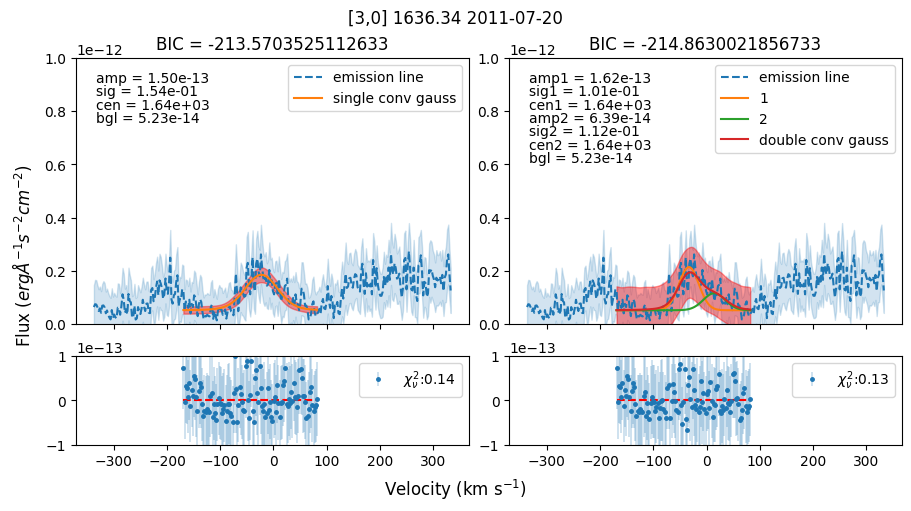

In [48]:
# for transit in BC_conf['transition'].unique():
plot_fits(BC_diff, transition='[3,0]', plot_vel=True)